Current working directory:
/home/aluoch/smart-waste-classifier/notebooks
Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 134s 424ms/step - accuracy: 0.6102 - loss: 1.1594 - val_accuracy: 0.2648 - val_loss: 2.2228
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 431ms/step - accuracy: 0.8089 - loss: 0.5950 - val_accuracy: 0.3550 - val_loss: 2.1756
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 429ms/step - accuracy: 0.8957 - loss: 0.3457 - val_accuracy: 0.4296 - val_loss: 2.0903
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 134s 438ms/step - accuracy: 0.9520 - loss: 0.1808 - val_accuracy: 0.5186 - val_loss: 1.9181
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 133s 434ms/step - accuracy: 0.9790 - loss: 0.0948 - val_accuracy: 0.6663 - val_loss: 1.2043
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 431ms/step - accuracy: 0.9877 - loss: 0.0608 - val_accuracy: 0.7054 - val_loss: 1.1077
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 134s 437ms/step - accuracy: 0.9894 - loss: 0.0437 - val_accuracy: 0.7197 - val_loss: 1.1499
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 133s 434ms/step - accuracy: 0.9872 -

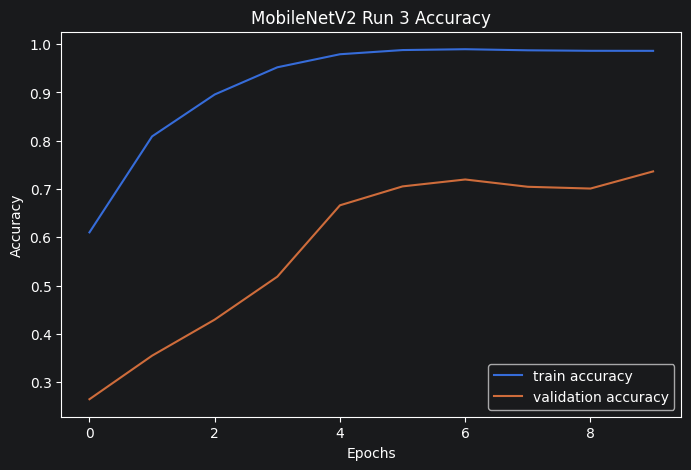

Saved MobileNet run 3 loss figure successfully!


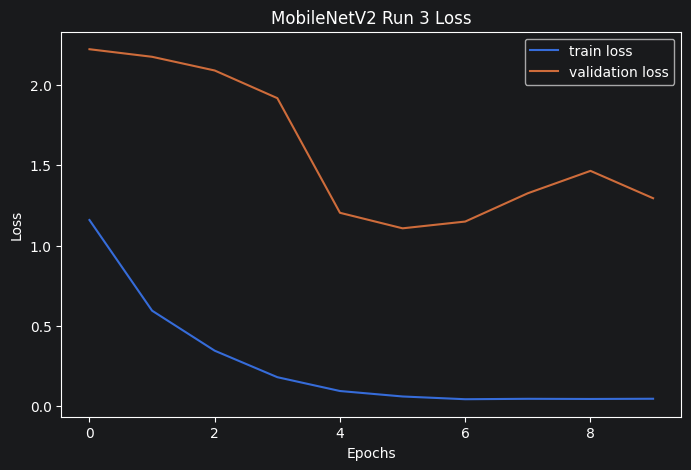

MobileNetV2 run 3 model saved successfully!


In [4]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

print("Current working directory:")
print(os.getcwd())

# Dataset loading
data_dir = "../data/standardized_256"

img_size = (224, 224)
batch_size = 32

# Train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Create output folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Load pretrained MobileNetV2 base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Fine-tuning
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Build MobileNetV2 model
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Training timer
start_time = time.time()

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# End timer
end_time = time.time()

print("Training time:", end_time - start_time, "seconds")

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title("MobileNetV2 Run 3 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/mobilenet_run3_accuracy.png")
print("Saved MobileNet run 3 accuracy image successfully!")

plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title("MobileNetV2 Run 3 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/mobilenet_run3_loss.png")
print("Saved MobileNet run 3 loss figure successfully!")

plt.show()

# Save model
model.save("../models/mobilenet_run3.keras")
print("MobileNetV2 run 3 model saved successfully!")